In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

In [3]:
#Used my own file path because I wanted to just do it in VSC
df = pd.read_csv("../Data/clean.csv", encoding='utf-8')
df.head()

,case_id,snapshot_at,created_at,channel,case_type,category,subcategory,priority,sla_target_hours,first_response_time_hours,...,customer_tenure_months,plan_tier,region_uk,age_band,gender,case_summary,sentiment,csat_score,tags,gender_clean
0,ND-2025-000400,2026-01-01 00:00:00+00:00,2025-03-01 08:15:22+00:00,email,service_request,billing_payments,vat_receipt,Medium,24.0,2.5,...,12,Pro,London,35-44,F,Need a VAT receipt for the last Orbit ID subsc...,Neutral,5.0,vat;subscription;invoice,Female
1,ND-2025-000401,2026-01-01 00:00:00+00:00,2025-03-01 09:02:10+00:00,webchat,service_request,account_admin,user_add_remove,Low,48.0,1.1,...,24,Standard,South East,25-34,M,How do I remove a user from our Polaris Board ...,Neutral,4.0,user_management;admin;polaris,Male
2,ND-2025-000402,2026-01-01 00:00:00+00:00,2025-03-01 09:30:45+00:00,email,incident,billing_payments,invoice_error,High,8.0,0.8,...,6,Enterprise,North West,45-54,M,The invoice amount for the Enterprise tier doe...,Negative,2.0,invoice;enterprise_tier;error,Male
3,ND-2025-000404,2026-01-01 00:00:00+00:00,2025-03-01 11:45:33+00:00,in_app,service_request,billing_payments,vat_receipt,Medium,24.0,3.5,...,18,Pro,Scotland,35-44,F,Where do I download the VAT invoice for my rec...,Neutral,5.0,vat;invoice;download,Female
4,ND-2025-000405,2026-01-01 00:00:00+00:00,2025-03-01 13:20:12+00:00,email,incident,bug,ui_glitch,High,8.0,1.2,...,36,Standard,London,25-34,M,The Polaris Board widget for revenue is overla...,Negative,3.0,bug;ui;widget;polaris,Male


In [4]:
df_filtered = df[
    df["age_band"].notna() &
    df["age_band"].astype(str).str.strip().ne("")
]
 
df_deduped = df_filtered.drop_duplicates()

In [5]:
df_filtered_drop = df_deduped.drop(columns=['first_response_time_hours', 'resolution_time_hours',
                      'escalated', 'assigned_team', 'escalation_team', 'gender', 'resolution_code'])

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report

In [7]:
df_clean = df_filtered_drop.copy()

In [8]:
df_clean.columns

Index(['case_id', 'snapshot_at', 'created_at', 'channel', 'case_type',
       'category', 'subcategory', 'priority', 'sla_target_hours', 'status',
       'customer_tenure_months', 'plan_tier', 'region_uk', 'age_band',
       'case_summary', 'sentiment', 'csat_score', 'tags', 'gender_clean'],
      dtype='str')

In [9]:
text_col = "case_summary"
 
cat_cols = ["channel", "case_type", "plan_tier", "created_at"]
 
num_cols = ["customer_tenure_months"]

cat_cols = list(dict.fromkeys(cat_cols))
num_cols = list(dict.fromkeys(num_cols))

 
# Keep only columns that actually exist (defensive programming)
cat_cols = [c for c in cat_cols if c in df_clean.columns]
num_cols = [c for c in num_cols if c in df_clean.columns]
 
# Build X / y
X = df_filtered_drop[cat_cols + num_cols + ([text_col] if text_col in df_clean.columns else [])]
y = df_filtered_drop["priority"]
 
# Fill missing text with empty string (TF-IDF can't handle NaN)
if text_col in X.columns:
    X[text_col] = X[text_col].fillna("")
 
# Train/test split (stratify to keep class balance)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [10]:
# Preprocessing blocks
transformers = []
 
if text_col in X.columns:
    transformers.append(
        ("text", TfidfVectorizer(ngram_range=(1, 2), min_df=2), text_col)
    )
 
if cat_cols:
    transformers.append(
        ("cat", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ]), cat_cols)
    )
 
if num_cols:
    transformers.append(
        ("num", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="median"))
        ]), num_cols)
    )

clf = DecisionTreeClassifier(max_depth=3, random_state=42)

preprocess = ColumnTransformer(transformers=transformers, remainder="drop")
model = Pipeline(steps=[
    ("preprocess", preprocess),
   ("clf", clf)
])

In [12]:
import optuna
from optuna.samplers import TPESampler

from sklearn.base import clone
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix


def objective(trial):
    # Suggest hyperparameters for the DecisionTreeClassifier
    params = {
        "clf__criterion": trial.suggest_categorical("criterion", ["gini", "entropy", "log_loss"]),
        "clf__splitter": trial.suggest_categorical("splitter", ["best", "random"]),
        "clf__max_depth": trial.suggest_int("max_depth", 2, 25),
        "clf__min_samples_split": trial.suggest_int("min_samples_split", 2, 50),
        "clf__min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 30),
        "clf__max_features": trial.suggest_categorical("max_features", [None, "sqrt", "log2"]),
        "clf__class_weight": trial.suggest_categorical("class_weight", [None, "balanced"]),
        # Cost-complexity pruning (0.0 = no pruning)
        "clf__ccp_alpha": trial.suggest_float("ccp_alpha", 0.0, 0.02),
    }

    # Clone your pipeline so each trial starts clean
    pipe = clone(model).set_params(**params)

    # CV scoring: for imbalanced classes, macro or weighted F1 is usually better than accuracy
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_val_score(
        pipe,
        X_train, y_train,
        scoring="f1_macro",   # try "f1_weighted" if you prefer
        cv=cv,
        n_jobs=-1
    )
    return scores.mean()

# Create and run the Optuna study
study = optuna.create_study(
    direction="maximize",
    sampler=TPESampler(seed=42)  # TPE is Optuna’s common default-style Bayesian sampler
)
study.optimize(objective, n_trials=50)

print("Best CV score (f1_macro):", study.best_value)
print("Best params:", study.best_params)

# Refit the best model on full training data
best_model = clone(model).set_params(**{f"clf__{k}": v for k, v in study.best_params.items() if not k.startswith("clf__")} )
# NOTE: Above line is for safety if you change naming; simplest is:
best_model = clone(model).set_params(**{f"clf__{k}": v for k, v in study.best_params.items()})

best_model.fit(X_train, y_train)



C:\Users\OscarReedman\Documents\Projects\OrderScript\Northstar-Desk-Decision-Support-Tool-\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[I 2026-03-03 20:22:56,688] A new study created in memory with name: no-name-a862ca39-6362-4380-aee4-7fa7369eb08f
[I 2026-03-03 20:23:04,974] Trial 0 finished with value: 0.2112343431450081 and parameters: {'criterion': 'entropy', 'splitter': 'best', 'max_depth': 5, 'min_samples_split': 4, 'min_samples_leaf': 26, 'max_features': 'sqrt', 'class_weight': None, 'ccp_alpha': 0.004246782213565523}. Best is trial 0 with value: 0.2112343431450081.
[I 2026-03-03 20:23:10,012] Trial 1 finished with value: 0.17902955184236063 and parameters: {'criterion': 'log_loss', 'splitter': 'best', 'max_depth': 8, 'min_samples_split': 31, 'min_samples_leaf': 5, 'max_features': 'log2', 'class_we

Best CV score (f1_macro): 0.6195713955256564
Best params: {'criterion': 'log_loss', 'splitter': 'best', 'max_depth': 10, 'min_samples_split': 25, 'min_samples_leaf': 18, 'max_features': None, 'class_weight': None, 'ccp_alpha': 0.011829204323290664}


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('text', ...), ('cat', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers 

In [13]:
# Evaluate
pred = best_model.predict(X_test)
 
print("\nClassification report:")
print(classification_report(y_test, pred))

 
# If you want probabilities (confidence):
if hasattr(best_model.named_steps["clf"], "predict_proba"):
    proba = best_model.predict_proba(X_test.iloc[:5])
    print("\nExample predicted probabilities (first 5 rows):")
    print(pd.DataFrame(proba, columns=best_model.named_steps["clf"].classes_))


Classification report:
              precision    recall  f1-score   support

        High       0.68      0.46      0.55        74
         Low       0.61      0.64      0.63        81
      Medium       0.65      0.71      0.68       146
      Urgent       0.60      0.70      0.64        40

    accuracy                           0.64       341
   macro avg       0.64      0.63      0.63       341
weighted avg       0.64      0.64      0.64       341


Example predicted probabilities (first 5 rows):
       High       Low    Medium    Urgent
0  0.019157  0.582375  0.379310  0.019157
1  0.655963  0.013761  0.192661  0.137615
2  0.410714  0.008929  0.080357  0.500000
3  0.019157  0.582375  0.379310  0.019157
4  0.000000  0.000000  1.000000  0.000000


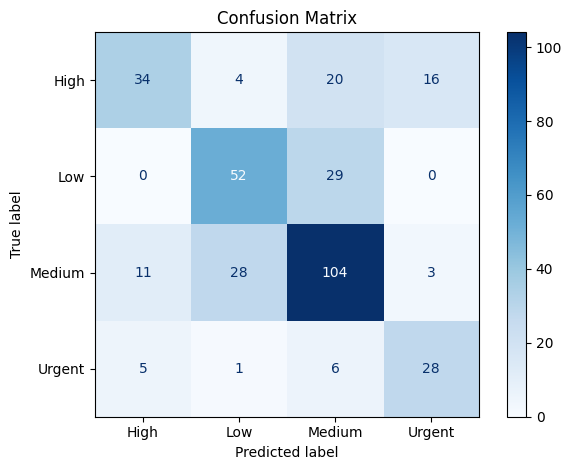

In [14]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay.from_predictions(
    y_test,
    pred,
    display_labels=['High', 'Low', 'Medium', 'Urgent'],
    cmap="Blues",
    colorbar=True
)

plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()
